In [1]:
import pandas as pd

path = "../data/proccessed/vinmec_articles_structured.jsonl"
df = pd.read_json(path, lines=True)

In [2]:
df.describe(include="all").T

,count,unique,top,freq
article_id,39856,39856,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,1
url,39856,39856,https://www.vinmec.com/vie/bai-viet/chi-so-loa...,1
categories,39856,20,[Sức khỏe phụ nữ],5487
breadcrumb,39856,22,"[Trang chủ, Trung tâm sức khoẻ phụ nữ]",5485
title,39856,39759,Điều trị trào ngược dạ dày thực quản như thế nào?,3
content_hash,39856,39856,a10977dfc08dd72880197343f4511748d0f1e124,1
raw_text,39856,39856,Chỉ số loãng xương là thước đo quan trọng để p...,1
blocks,39856,39856,"[{'type': 'paragraph', 'text': 'Chỉ số loãng x...",1


In [3]:
df.shape

(39856, 8)

In [4]:
df.head().T

,0,1,2,3,4
article_id,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,fe6d19eb62fc8e13038c3dddf64a7bd9e7e16c40,307144d5a216244f3b62427cdabef0919586db31,8b71f99cbde811781eb7ec5d11961de9d5a586f7,5bc8598459d9619d5bbaca87a6129358fd0e46ff
url,https://www.vinmec.com/vie/bai-viet/chi-so-loa...,https://www.vinmec.com/vie/bai-viet/cham-cuu-d...,https://www.vinmec.com/vie/bai-viet/gay-xuong-...,https://www.vinmec.com/vie/bai-viet/thoat-vi-d...,https://www.vinmec.com/vie/bai-viet/kham-gout-...
categories,[Chấn thương chỉnh hình - Y khoa],[Chấn thương chỉnh hình - Y khoa],[Chấn thương chỉnh hình - Y khoa],[Chấn thương chỉnh hình - Y khoa],[Chấn thương chỉnh hình - Y khoa]
breadcrumb,"[Trang chủ, Chấn thương chỉnh hình - Y học thể...","[Trang chủ, Chấn thương chỉnh hình - Y học thể...","[Trang chủ, Chấn thương chỉnh hình - Y học thể...","[Trang chủ, Chấn thương chỉnh hình - Y học thể...","[Trang chủ, Chấn thương chỉnh hình - Y học thể..."
title,Chỉ số loãng xương và những ai nên đo loãng xư...,"Châm cứu đau thần kinh tọa và thông tin, lưu ý...",Gãy xương hốc mắt có nguy hiểm không? Điều trị...,Thoát vị đĩa đệm có dẫn tới hội chứng đuôi ngự...,Khám gout ở đâu tốt nhất và vì sao nên chữa bệ...
content_hash,a10977dfc08dd72880197343f4511748d0f1e124,58a1b10469bde096820532ba7582823794bb206e,6a05963a33097b0ecf1d848459fc186d9fe4256c,caabf69a2117e8e316d28eba8811ec7ff85f5044,a52ca7ee1f227e598c143a36c05e536df9e5a267
raw_text,Chỉ số loãng xương là thước đo quan trọng để p...,Châm cứu đau thần kinh tọa cần được thực hiện ...,Gãy xương hốc mắt có nguy hiểm không là vấn đề...,Thoát vị đĩa đệm có dẫn tới hội chứng đuôi ngự...,Khám gout ở đâu tốt là vấn đề quan trọng mà nh...
blocks,"[{'type': 'paragraph', 'text': 'Chỉ số loãng x...","[{'type': 'paragraph', 'text': 'Châm cứu đau t...","[{'type': 'paragraph', 'text': 'Gãy xương hốc ...","[{'type': 'paragraph', 'text': 'Thoát vị đĩa đ...","[{'type': 'paragraph', 'text': 'Khám gout ở đâ..."


In [5]:
import json

row_idx = 0
print(json.dumps(df.loc[row_idx, "blocks"], ensure_ascii=False, indent=2))

[
  {
    "type": "paragraph",
    "text": "Chỉ số loãng xương là thước đo quan trọng để phát hiện sớm bệnh lý này, từ đó có thể ngăn ngừa các biến chứng nguy hiểm. Thông thường, loãng xương không có triệu chứng rõ ràng ở giai đoạn đầu nhưng khi tình trạng trở nên nghiêm trọng, xương sẽ yếu đi và dễ gãy. Do đó, việc theo dõi chỉ số loãng xương, đặc biệt ở nhóm người có nguy cơ cao là điều cần thiết để bảo vệ sức khỏe xương.",
    "heading_path": [],
    "order": 1
  },
  {
    "type": "paragraph",
    "text": "Bài viết này được viết dưới sự hướng dẫn chuyên môn của các bác sĩ thuộc khoa Chấn thương chỉnh hình & Y học thể thao Bệnh viện Đa khoa Quốc tế Vinmec.",
    "heading_path": [],
    "order": 2
  },
  {
    "type": "heading",
    "level": 2,
    "text": "1. Loãng xương là bệnh gì?",
    "heading_path": [
      "1. Loãng xương là bệnh gì?"
    ],
    "order": 3
  },
  {
    "type": "paragraph",
    "text": "Loãng xương là một bệnh lý thường không bộc lộ nhiều triệu chứng cho đến kh

## Block-level inspection

Các cell bên dưới chuyển `blocks` thành bảng phẳng để thống kê và trực quan hóa cấu trúc nội dung cho RAG.


In [6]:
from IPython.display import display
import matplotlib.pyplot as plt

records = []
for article_idx, row in df.reset_index(drop=True).iterrows():
    blocks = row["blocks"]
    for block in blocks:
        records.append(
            {
                "article_idx": article_idx,
                "article_id": row["article_id"],
                "title": row["title"],
                "block_type": block.get("type"),
                "text": block.get("text", ""),
                "text_length": len(block.get("text", "")),
                "heading_path": block.get("heading_path", []),
                "heading_depth": len(block.get("heading_path", [])),
                "heading_level": block.get("level"),
                "order": block.get("order"),
            }
        )

blocks_df = pd.DataFrame(records)
article_block_stats = pd.DataFrame({
    "article_idx": df.reset_index(drop=True).index,
    "title": df["title"].values,
    "block_count": df["blocks"].map(len).values,
    "raw_text_length": df["raw_text"].str.len().values,
})

print(f"articles: {len(df):,}")
print(f"blocks: {len(blocks_df):,}")
blocks_df.head()


articles: 39,856
blocks: 1,481,057


,article_idx,article_id,title,block_type,text,text_length,heading_path,heading_depth,heading_level,order
0,0,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,Chỉ số loãng xương và những ai nên đo loãng xư...,paragraph,Chỉ số loãng xương là thước đo quan trọng để p...,383,[],0,NaN,1
1,0,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,Chỉ số loãng xương và những ai nên đo loãng xư...,paragraph,Bài viết này được viết dưới sự hướng dẫn chuyê...,151,[],0,NaN,2
2,0,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,Chỉ số loãng xương và những ai nên đo loãng xư...,heading,1. Loãng xương là bệnh gì?,26,[1. Loãng xương là bệnh gì?],1,2.0,3
3,0,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,Chỉ số loãng xương và những ai nên đo loãng xư...,paragraph,Loãng xương là một bệnh lý thường không bộc lộ...,318,[1. Loãng xương là bệnh gì?],1,NaN,4
4,0,cfc49fc857ed1d7b8c1995db73c4a4101f034f64,Chỉ số loãng xương và những ai nên đo loãng xư...,paragraph,Trong vòng 6 tháng đầu sau khi gãy cổ xương đù...,165,[1. Loãng xương là bệnh gì?],1,NaN,5


In [7]:
type_summary = (
    blocks_df.groupby("block_type")
    .agg(
        block_count=("block_type", "size"),
        avg_text_length=("text_length", "mean"),
        median_text_length=("text_length", "median"),
        max_text_length=("text_length", "max"),
        avg_heading_depth=("heading_depth", "mean"),
    )
    .sort_values("block_count", ascending=False)
)

article_summary = article_block_stats["block_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T
depth_summary = blocks_df["heading_depth"].describe().to_frame().T

display(type_summary.round(2))
display(article_summary.round(2))
display(depth_summary.round(2))


,block_count,avg_text_length,median_text_length,max_text_length,avg_heading_depth
block_type,,,,,
paragraph,657828,211.52,196.0,6389,0.89
list_item,647238,73.67,31.0,2182,1.11
heading,175476,36.96,35.0,409,1.39
table,515,648.94,452.0,6569,1.28


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
block_count,39856.0,37.16,20.25,2.0,20.0,34.0,48.0,63.0,74.0,104.0,294.0


,count,mean,std,min,25%,50%,75%,max
heading_depth,1481057.0,1.05,0.68,0.0,1.0,1.0,1.0,3.0


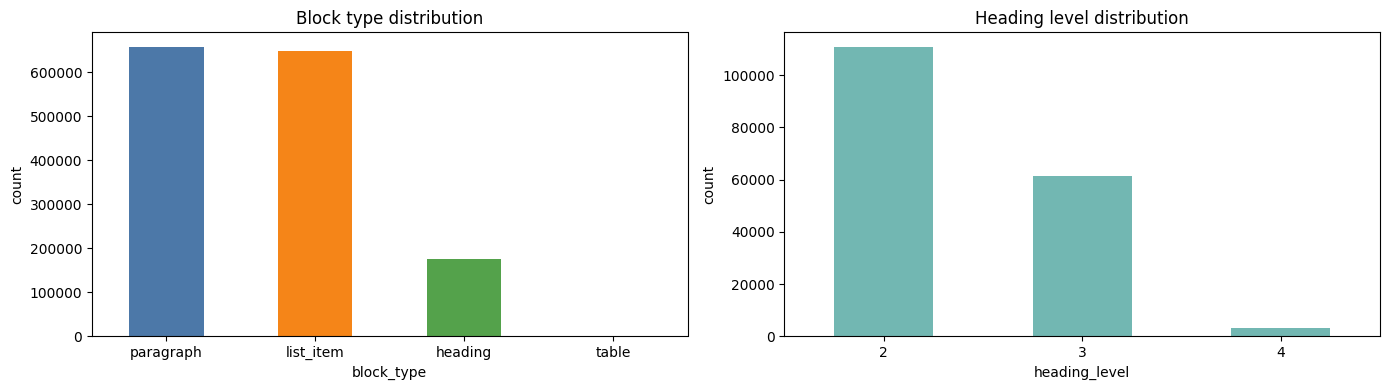

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_counts = blocks_df["block_type"].value_counts().sort_values(ascending=False)
type_counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
axes[0].set_title("Block type distribution")
axes[0].set_xlabel("block_type")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

heading_level_counts = blocks_df["heading_level"].dropna().astype(int).value_counts().sort_index()
heading_level_counts.plot(kind="bar", ax=axes[1], color="#72B7B2")
axes[1].set_title("Heading level distribution")
axes[1].set_xlabel("heading_level")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()


,article_idx,title,block_count,raw_text_length
13082,13082,Các mốc phát triển mà trẻ nhỏ nên đạt được,294,16462
2392,2392,Chữa thoái hóa khớp gối theo y học cổ truyền,289,19892
17617,17617,Hướng dẫn đầy đủ về các bài tập kéo giãn cơ thể,244,20508
18428,18428,Vitamin hòa tan trong nước: Phức hợp C và B,211,18095
5479,5479,21 triệu chứng khó chịu khi mang thai: Nguyên ...,202,19232
29737,29737,11 bệnh ung thư đường tiêu hóa,191,16686
10799,10799,Thực đơn cho trẻ còi xương suy dinh dưỡng,190,10189
25549,25549,Các vấn đề thường gặp ở thực quản,188,23233
5215,5215,Biện pháp tránh thai nào ít tác dụng phụ nhất?,188,18002
11488,11488,Thú vị: 172 tên biệt danh cho ti giả của bé,187,3589


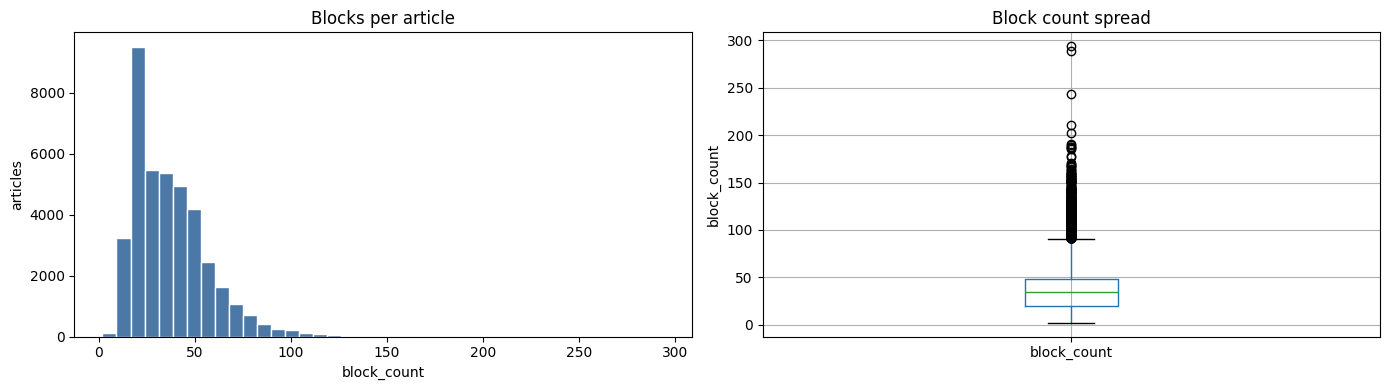

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

article_block_stats["block_count"].plot(kind="hist", bins=40, ax=axes[0], color="#4C78A8", edgecolor="white")
axes[0].set_title("Blocks per article")
axes[0].set_xlabel("block_count")
axes[0].set_ylabel("articles")

article_block_stats.boxplot(column="block_count", ax=axes[1])
axes[1].set_title("Block count spread")
axes[1].set_ylabel("block_count")

plt.tight_layout()
article_block_stats.sort_values("block_count", ascending=False).head(10)


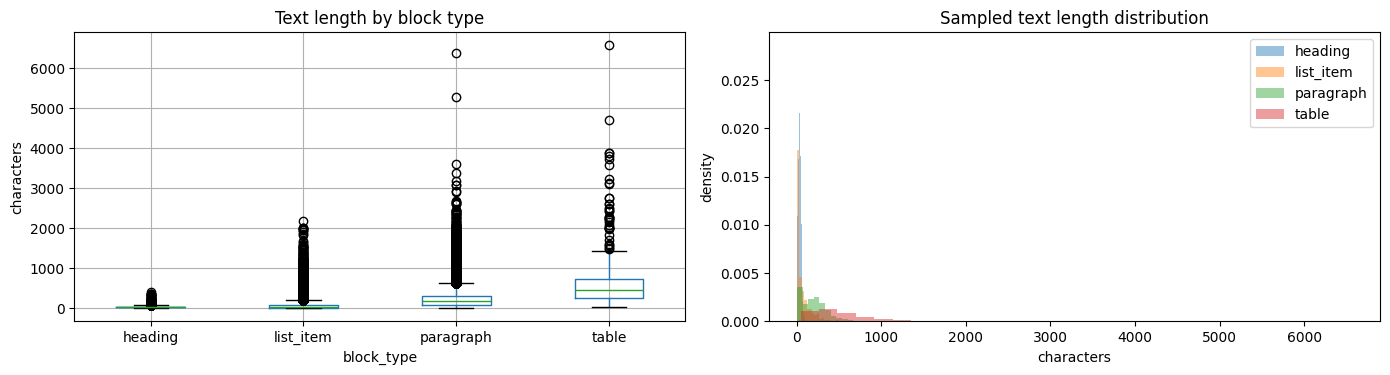

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

blocks_df.boxplot(column="text_length", by="block_type", ax=axes[0])
axes[0].set_title("Text length by block type")
axes[0].set_xlabel("block_type")
axes[0].set_ylabel("characters")

sampled_parts = []
for block_type, subset in blocks_df.groupby("block_type"):
    sampled_parts.append(subset.sample(n=min(len(subset), 2000), random_state=42))
sampled = pd.concat(sampled_parts, ignore_index=True)

for block_type, subset in sampled.groupby("block_type"):
    axes[1].hist(subset["text_length"], bins=30, alpha=0.45, density=True, label=block_type)
axes[1].set_title("Sampled text length distribution")
axes[1].set_xlabel("characters")
axes[1].set_ylabel("density")
axes[1].legend()

plt.suptitle("")
plt.tight_layout()


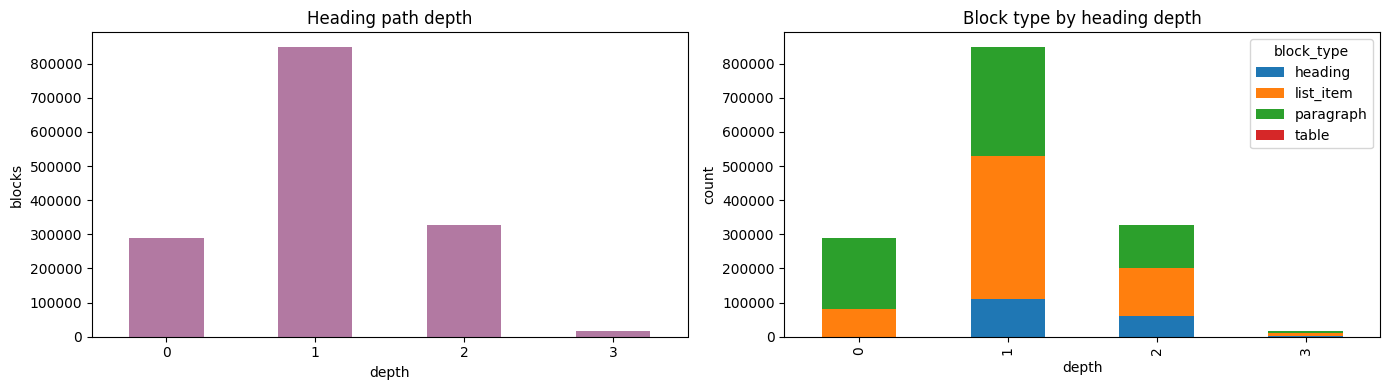

In [11]:
heading_depth_counts = blocks_df["heading_depth"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

heading_depth_counts.plot(kind="bar", ax=axes[0], color="#B279A2")
axes[0].set_title("Heading path depth")
axes[0].set_xlabel("depth")
axes[0].set_ylabel("blocks")
axes[0].tick_params(axis="x", rotation=0)

(blocks_df.groupby(["heading_depth", "block_type"]).size().unstack(fill_value=0)).plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Block type by heading depth")
axes[1].set_xlabel("depth")
axes[1].set_ylabel("count")
axes[1].legend(title="block_type")

plt.tight_layout()


In [12]:
row_idx = 0
article_blocks = blocks_df.loc[blocks_df["article_idx"] == row_idx].copy()
article_blocks[["order", "block_type", "heading_level", "heading_depth", "text_length", "heading_path", "text"]]


,order,block_type,heading_level,heading_depth,text_length,heading_path,text
0,1,paragraph,NaN,0,383,[],Chỉ số loãng xương là thước đo quan trọng để p...
1,2,paragraph,NaN,0,151,[],Bài viết này được viết dưới sự hướng dẫn chuyê...
2,3,heading,2.0,1,26,[1. Loãng xương là bệnh gì?],1. Loãng xương là bệnh gì?
3,4,paragraph,NaN,1,318,[1. Loãng xương là bệnh gì?],Loãng xương là một bệnh lý thường không bộc lộ...
4,5,paragraph,NaN,1,165,[1. Loãng xương là bệnh gì?],Trong vòng 6 tháng đầu sau khi gãy cổ xương đù...
5,6,paragraph,NaN,1,322,[1. Loãng xương là bệnh gì?],"Trước tuổi 30, cơ thể tạo xương nhanh hơn phá ..."
6,7,paragraph,NaN,1,235,[1. Loãng xương là bệnh gì?],Cấu trúc và khối lượng xương tốt khi còn trẻ g...
7,8,paragraph,NaN,1,383,[1. Loãng xương là bệnh gì?],"Do đó, khi xương thiếu hụt canxi và các khoáng..."
8,9,paragraph,NaN,1,163,[1. Loãng xương là bệnh gì?],Tình trạng loãng xương trong cộng đồng ngày na...
9,10,paragraph,NaN,1,180,[1. Loãng xương là bệnh gì?],Chính vì những biến chứng nghiêm trọng mà việc...


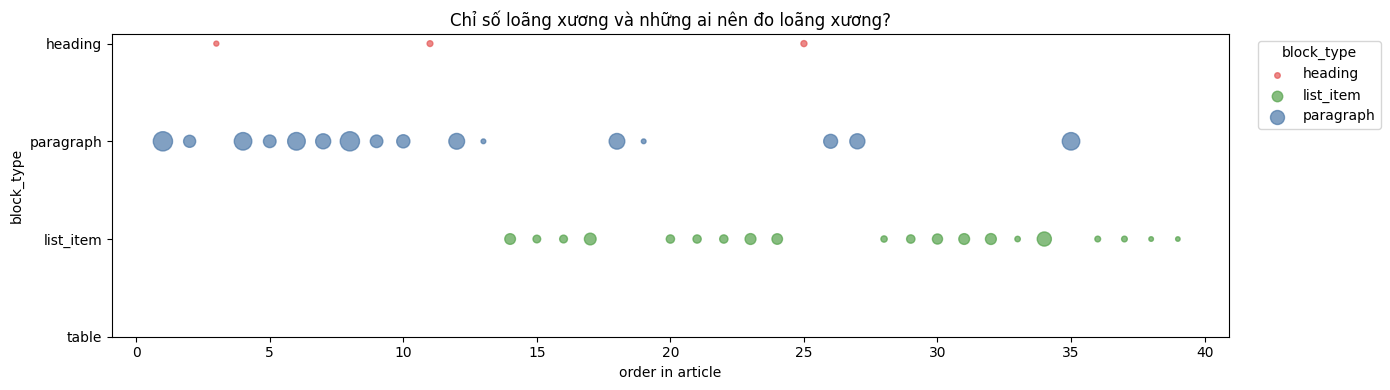

In [13]:
row_idx = 0
article_blocks = blocks_df.loc[blocks_df["article_idx"] == row_idx].copy()
color_map = {"heading": "#E45756", "paragraph": "#4C78A8", "list_item": "#54A24B", "table": "#B279A2"}
y_map = {"heading": 3, "paragraph": 2, "list_item": 1, "table": 0}

fig, ax = plt.subplots(figsize=(14, 4))
for block_type, subset in article_blocks.groupby("block_type"):
    ax.scatter(
        subset["order"],
        subset["block_type"].map(y_map),
        s=subset["text_length"].clip(lower=20, upper=600) / 2,
        alpha=0.7,
        label=block_type,
        color=color_map.get(block_type, "#999999"),
    )

ax.set_title(df.loc[row_idx, "title"])
ax.set_xlabel("order in article")
ax.set_ylabel("block_type")
ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))
ax.legend(title="block_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


In [14]:
def build_rag_chunks_df(df, *, max_chars=1200):
    def heading_prefix(heading_path):
        return " > ".join(heading_path) if heading_path else "ROOT"

    def compose_chunk_text(heading_path, texts):
        prefix = heading_prefix(heading_path)
        body = "\n".join(texts).strip()
        return f"{prefix}\n{body}" if body else prefix

    rows = []

    for article_idx, row in df.reset_index(drop=True).iterrows():
        blocks = row["blocks"]
        content_blocks = [block for block in blocks if block.get("type") != "heading"]

        # Strategy 1: one chunk per content block.
        for chunk_local_idx, block in enumerate(content_blocks, start=1):
            rows.append(
                {
                    "strategy": "single_block",
                    "article_idx": article_idx,
                    "article_id": row["article_id"],
                    "title": row["title"],
                    "chunk_local_idx": chunk_local_idx,
                    "heading_path": block.get("heading_path", []),
                    "heading_prefix": heading_prefix(block.get("heading_path", [])),
                    "block_orders": [block.get("order")],
                    "block_types": [block.get("type")],
                    "block_count": 1,
                    "char_count": len(block.get("text", "")),
                    "chunk_text": compose_chunk_text(block.get("heading_path", []), [block.get("text", "")]),
                }
            )

        # Strategy 2: group all contiguous content blocks under the same heading path.
        section_chunks = []
        current = None
        for block in content_blocks:
            key = tuple(block.get("heading_path", []))
            if current is None or tuple(current["heading_path"]) != key:
                if current is not None:
                    section_chunks.append(current)
                current = {
                    "heading_path": list(key),
                    "block_orders": [],
                    "block_types": [],
                    "texts": [],
                }
            current["block_orders"].append(block.get("order"))
            current["block_types"].append(block.get("type"))
            current["texts"].append(block.get("text", ""))
        if current is not None:
            section_chunks.append(current)

        for chunk_local_idx, chunk in enumerate(section_chunks, start=1):
            chunk_text = compose_chunk_text(chunk["heading_path"], chunk["texts"])
            rows.append(
                {
                    "strategy": "section_group",
                    "article_idx": article_idx,
                    "article_id": row["article_id"],
                    "title": row["title"],
                    "chunk_local_idx": chunk_local_idx,
                    "heading_path": chunk["heading_path"],
                    "heading_prefix": heading_prefix(chunk["heading_path"]),
                    "block_orders": chunk["block_orders"],
                    "block_types": chunk["block_types"],
                    "block_count": len(chunk["block_orders"]),
                    "char_count": len(chunk_text),
                    "chunk_text": chunk_text,
                }
            )

        # Strategy 3: keep section boundaries but split long sections by character budget.
        budget_chunks = []
        for section in section_chunks:
            part = None
            for order, block_type, text in zip(section["block_orders"], section["block_types"], section["texts"]):
                candidate_texts = [] if part is None else part["texts"][:]
                candidate_texts.append(text)
                candidate_len = len(compose_chunk_text(section["heading_path"], candidate_texts))
                if part is not None and candidate_len > max_chars:
                    budget_chunks.append(part)
                    part = None
                if part is None:
                    part = {
                        "heading_path": section["heading_path"][:],
                        "block_orders": [],
                        "block_types": [],
                        "texts": [],
                    }
                part["block_orders"].append(order)
                part["block_types"].append(block_type)
                part["texts"].append(text)
            if part is not None:
                budget_chunks.append(part)

        for chunk_local_idx, chunk in enumerate(budget_chunks, start=1):
            chunk_text = compose_chunk_text(chunk["heading_path"], chunk["texts"])
            rows.append(
                {
                    "strategy": f"section_budget_{max_chars}",
                    "article_idx": article_idx,
                    "article_id": row["article_id"],
                    "title": row["title"],
                    "chunk_local_idx": chunk_local_idx,
                    "heading_path": chunk["heading_path"],
                    "heading_prefix": heading_prefix(chunk["heading_path"]),
                    "block_orders": chunk["block_orders"],
                    "block_types": chunk["block_types"],
                    "block_count": len(chunk["block_orders"]),
                    "char_count": len(chunk_text),
                    "chunk_text": chunk_text,
                }
            )

    rag_chunks_df = pd.DataFrame(rows)
    rag_chunks_df["chunk_id"] = (
        rag_chunks_df["strategy"]
        + "::"
        + rag_chunks_df["article_id"]
        + "::"
        + rag_chunks_df["chunk_local_idx"].astype(str)
    )
    return rag_chunks_df[
        [
            "strategy",
            "chunk_id",
            "article_idx",
            "article_id",
            "title",
            "chunk_local_idx",
            "heading_path",
            "heading_prefix",
            "block_orders",
            "block_types",
            "block_count",
            "char_count",
            "chunk_text",
        ]
    ]


rag_chunks_df = build_rag_chunks_df(df, max_chars=1200)
preview_row_idx = 0
preview_columns = [
    "strategy",
    "chunk_local_idx",
    "heading_prefix",
    "block_orders",
    "block_types",
    "block_count",
    "char_count",
    "chunk_text",
]

chunk_summary = (
    rag_chunks_df.groupby("strategy")
    .agg(
        chunk_count=("chunk_id", "size"),
        avg_blocks=("block_count", "mean"),
        median_blocks=("block_count", "median"),
        avg_chars=("char_count", "mean"),
        median_chars=("char_count", "median"),
        max_chars=("char_count", "max"),
    )
    .round(2)
)

display(chunk_summary)
display(
    rag_chunks_df.loc[rag_chunks_df["article_idx"] == preview_row_idx, preview_columns]
    .sort_values(["strategy", "chunk_local_idx"])
)


,chunk_count,avg_blocks,median_blocks,avg_chars,median_chars,max_chars
strategy,,,,,,
section_budget_1200,284450,4.59,3.0,707.45,705.0,6635
section_group,207212,6.30,4.0,954.82,703.0,33782
single_block,1305581,1.00,1.0,143.35,92.0,6569


,strategy,chunk_local_idx,heading_prefix,block_orders,block_types,block_count,char_count,chunk_text
40,section_budget_1200,1,ROOT,"[1, 2]","[paragraph, paragraph]",2,540,ROOT\nChỉ số loãng xương là thước đo quan trọn...
41,section_budget_1200,2,1. Loãng xương là bệnh gì?,"[4, 5, 6, 7]","[paragraph, paragraph, paragraph, paragraph]",4,1070,1. Loãng xương là bệnh gì?\nLoãng xương là một...
42,section_budget_1200,3,1. Loãng xương là bệnh gì?,"[8, 9, 10]","[paragraph, paragraph, paragraph]",3,755,"1. Loãng xương là bệnh gì?\nDo đó, khi xương t..."
43,section_budget_1200,4,2. Chỉ số loãng xương là bao nhiêu?,"[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]","[paragraph, paragraph, list_item, list_item, l...",11,1199,2. Chỉ số loãng xương là bao nhiêu?\nBác sĩ th...
44,section_budget_1200,5,2. Chỉ số loãng xương là bao nhiêu?,"[23, 24]","[list_item, list_item]",2,274,2. Chỉ số loãng xương là bao nhiêu?\nZ-score d...
45,section_budget_1200,6,3. Những ai nên đo chỉ số loãng xương?,"[26, 27, 28, 29, 30, 31, 32, 33, 34]","[paragraph, paragraph, list_item, list_item, l...",9,1184,3. Những ai nên đo chỉ số loãng xương?\nĐo mật...
46,section_budget_1200,7,3. Những ai nên đo chỉ số loãng xương?,"[35, 36, 37, 38, 39]","[paragraph, list_item, list_item, list_item, l...",5,471,3. Những ai nên đo chỉ số loãng xương?\nNhìn c...
36,section_group,1,ROOT,"[1, 2]","[paragraph, paragraph]",2,540,ROOT\nChỉ số loãng xương là thước đo quan trọn...
37,section_group,2,1. Loãng xương là bệnh gì?,"[4, 5, 6, 7, 8, 9, 10]","[paragraph, paragraph, paragraph, paragraph, p...",7,1799,1. Loãng xương là bệnh gì?\nLoãng xương là một...
38,section_group,3,2. Chỉ số loãng xương là bao nhiêu?,"[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2...","[paragraph, paragraph, list_item, list_item, l...",13,1438,2. Chỉ số loãng xương là bao nhiêu?\nBác sĩ th...
